In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam
from mlxtend.plotting import decision_regions

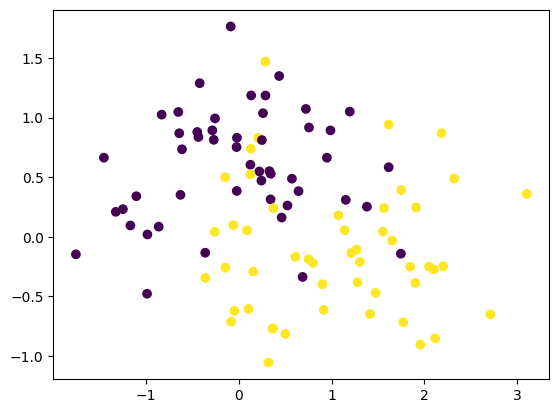

In [ ]:
from sklearn.datasets import make_moons
X,y=make_moons(100,noise=0.4,random_state=42)
plt.scatter(X[:,0],X[:,1],c=y)
plt.show()

In [ ]:
model=Sequential()
model.add(Dense(128,input_dim=2,activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(1,activation='sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,057 (82.25 KB)

 Trainable params: 21,057 (82.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
adam=Adam(learning_rate=0.01)
model.compile(loss='binary_crossentropy',optimizer=adam,metrics=['accuracy'])
history=model.fit(X,y,epochs=2000, validation_split=0.2,verbose=True)

Epoch 1/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 654ms/step - accuracy: 0.7250 - loss: 0.6047 - val_accuracy: 0.7500 - val_loss: 0.4927
Epoch 2/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.8625 - loss: 0.3770 - val_accuracy: 0.8000 - val_loss: 0.4932
Epoch 3/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8500 - loss: 0.4215 - val_accuracy: 0.8500 - val_loss: 0.5477
Epoch 4/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8250 - loss: 0.3802 - val_accuracy: 0.8500 - val_loss: 0.4718
Epoch 5/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8375 - loss: 0.3234 - val_accuracy: 0.8500 - val_loss: 0.4540
Epoch 6/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8500 - loss: 0.3228 - val_accuracy: 0.8500 - val_loss: 0.4506
Epoch 7/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8625 - loss: 0.3208 - val_accuracy: 0.8500 - val_loss: 0.4521
Epoch 8/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8500 - loss: 0.3139 - val_accuracy: 0.8500 - 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


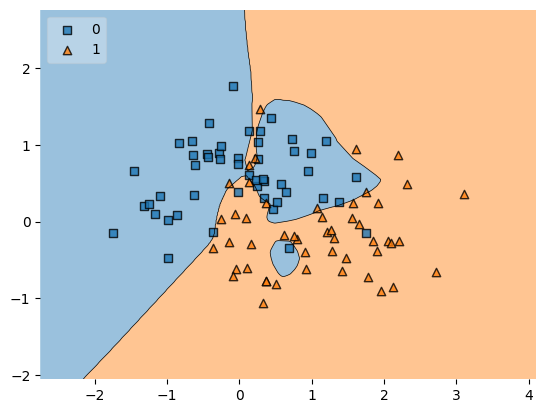

In [ ]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X, y.astype('int'), clf=model, legend=2)
plt.show()

# **Regularization**

In [ ]:
from tensorflow.keras.regularizers import l2

model = Sequential()

model.add(Dense(128, input_dim=2, activation='relu', kernel_regularizer=l2(0.01)))
model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.01)))
model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.01)))
model.add(Dense(1, activation='sigmoid', kernel_regularizer=l2(0.01)))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,057 (82.25 KB)

 Trainable params: 21,057 (82.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
adam=Adam(learning_rate=0.01)
model.compile(loss='binary_crossentropy',optimizer=adam,metrics=['accuracy'])
history1=model.fit(X,y,epochs=2000, validation_split=0.2,verbose=True)

Epoch 1/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 673ms/step - accuracy: 0.5750 - loss: 2.3044 - val_accuracy: 0.7500 - val_loss: 1.7235
Epoch 2/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7875 - loss: 1.5006 - val_accuracy: 0.8500 - val_loss: 1.1964
Epoch 3/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8250 - loss: 1.0177 - val_accuracy: 0.8500 - val_loss: 0.8976
Epoch 4/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8250 - loss: 0.7730 - val_accuracy: 0.8000 - val_loss: 0.7419
Epoch 5/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8500 - loss: 0.6182 - val_accuracy: 0.8500 - val_loss: 0.6638
Epoch 6/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8500 - loss: 0.5683 - val_accuracy: 0.8500 - val_loss: 0.6472
Epoch 7/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8500 - loss: 0.5553 - val_accuracy: 0.8500 - val_loss: 0.6245
Epoch 8/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8625 - loss: 0.5387 - val_accuracy: 0.8000 - 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step


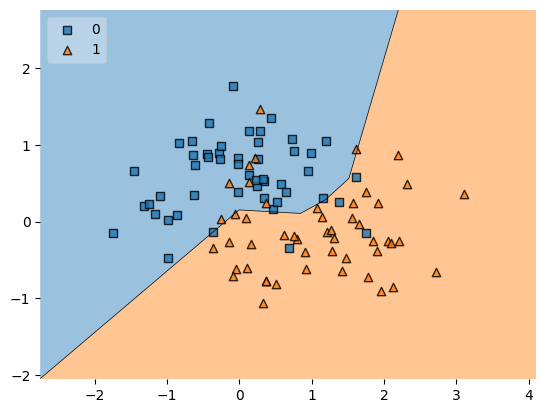

In [ ]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X, y.astype('int'), clf=model, legend=2)
plt.show()

# **L1 Regularization**

In [ ]:
from tensorflow.keras.regularizers import l1

model = Sequential()

model.add(Dense(128, input_dim=2, activation='relu', kernel_regularizer=l1(0.01)))
model.add(Dense(128, activation='relu', kernel_regularizer=l1(0.01)))
model.add(Dense(32, activation='relu', kernel_regularizer=l1(0.01)))
model.add(Dense(1, activation='sigmoid', kernel_regularizer=l1(0.01)))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,057 (82.25 KB)

 Trainable params: 21,057 (82.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
adam=Adam(learning_rate=0.01)
model.compile(loss='binary_crossentropy',optimizer=adam,metrics=['accuracy'])
history1=model.fit(X,y,epochs=2000, validation_split=0.2,verbose=True)

Epoch 1/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 834ms/step - accuracy: 0.6750 - loss: 15.8962 - val_accuracy: 0.8500 - val_loss: 12.0080
Epoch 2/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8375 - loss: 10.8241 - val_accuracy: 0.8000 - val_loss: 7.9330
Epoch 3/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8000 - loss: 7.0741 - val_accuracy: 0.7500 - val_loss: 5.0915
Epoch 4/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8125 - loss: 4.5707 - val_accuracy: 0.7000 - val_loss: 3.5031
Epoch 5/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8125 - loss: 3.2837 - val_accuracy: 0.7000 - val_loss: 3.0173
Epoch 6/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7750 - loss: 3.0134 - val_accuracy: 0.7000 - val_loss: 2.9642
Epoch 7/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7875 - loss: 2.8581 - val_accuracy: 0.6500 - val_loss: 2.6180
Epoch 8/2000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7750 - loss: 2.4575 - val_accuracy: 0.7500

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step


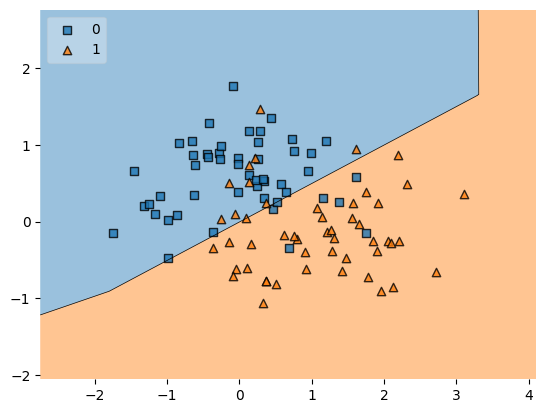

In [ ]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X, y.astype('int'), clf=model, legend=2)
plt.show()